# 04_Merge_Obs_To_Main
## Xiaonan Wang
## 17Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"16/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

In [5]:
x_all = sc.read_h5ad(datadir + "xenium.h5ad")
MA = sc.read_h5ad(outdir + 'MA.h5ad')
AM = sc.read_h5ad(outdir + 'AM_updated.h5ad')
# x_epi = sc.read_h5ad(outdir + 'epi_updated.h5ad')

In [6]:
x_all.obs["CellType_refined"] = (
    x_all.obs["celltype_final"]
    .astype(object)
)

In [9]:
x_all, report_MA = source.merge_obs_to_main(
    main_adata=x_all,
    subset_adata=MA,
    columns={
        "MA_group": "CellType_refined",
    },
    overwrite=True,
    strict_subset=True,
    source_name="x_MA",
)

In [10]:
x_all, report_AM = source.merge_obs_to_main(
    main_adata=x_all,
    subset_adata=AM,
    columns={
        "MHCIIhi_score": "MHCIIhi_score",
        "MHCII_group": "MHCII_group",
        "MHCIIhi_score_HC": "MHCIIhi_score_HC",
        "MHCII_group_HC": "MHCII_group_HC",
    },
    overwrite=True,
    strict_subset=True,
    source_name="AM",
)

In [9]:
# x_all, report_epi = merge_obs_to_main(
#     main_adata=x_all,
#     subset_adata=x_epi,
#     columns={
#         "CellType": "CellType_refined",
#     },
#     overwrite=True,
#     strict_subset=True,
#     source_name="x_epi",
# )

In [11]:
x_all.obs['MHCII_group'].value_counts()

MHCII_group
MHCIIlo    11660
MHCIIhi     5456
Name: count, dtype: int64

In [12]:
x_all.obs['MHCII_group_HC'].value_counts()

MHCII_group_HC
MHCIIlo    12750
MHCIIhi     4366
Name: count, dtype: int64

In [14]:
merge_report = pd.concat(
    [
        report_MA,
        report_AM,
    ],
    ignore_index=True,
)

display(merge_report)

,source,source_column,destination_column,n_source_cells,n_matched_cells,n_source_only_cells,n_nonmissing_values,n_values_written,overwrite
0,x_MA,MA_group,CellType_refined,33375,33375,0,33375,33375,True
1,AM,MHCIIhi_score,MHCIIhi_score,17116,17116,0,17116,17116,True
2,AM,MHCII_group,MHCII_group,17116,17116,0,17116,17116,True
3,AM,MHCIIhi_score_HC,MHCIIhi_score_HC,17116,17116,0,17116,17116,True
4,AM,MHCII_group_HC,MHCII_group_HC,17116,17116,0,17116,17116,True


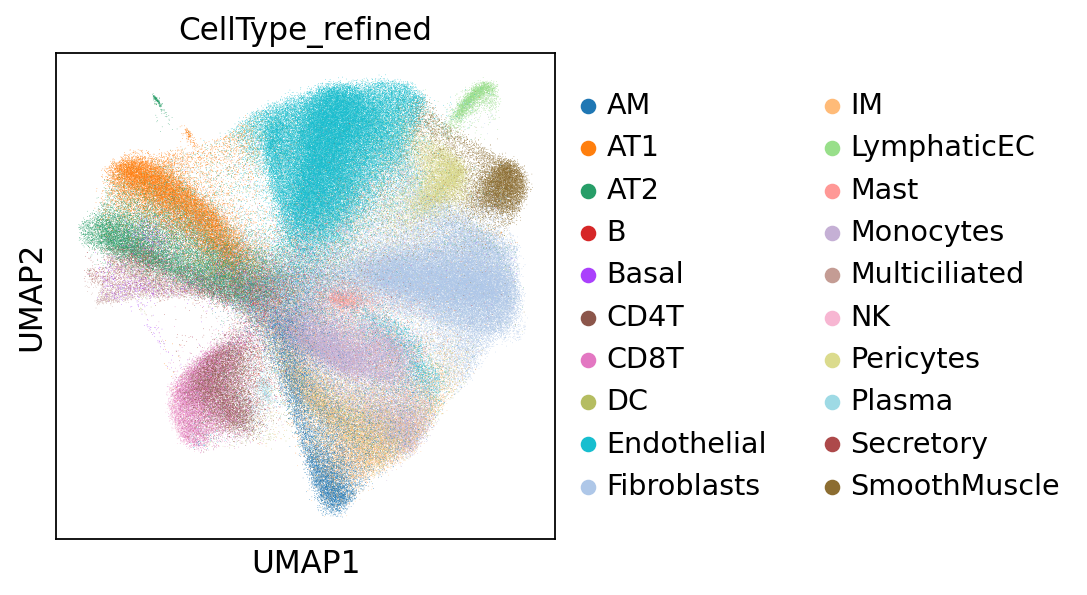

In [15]:
sc.pl.umap(x_all, color='CellType_refined')

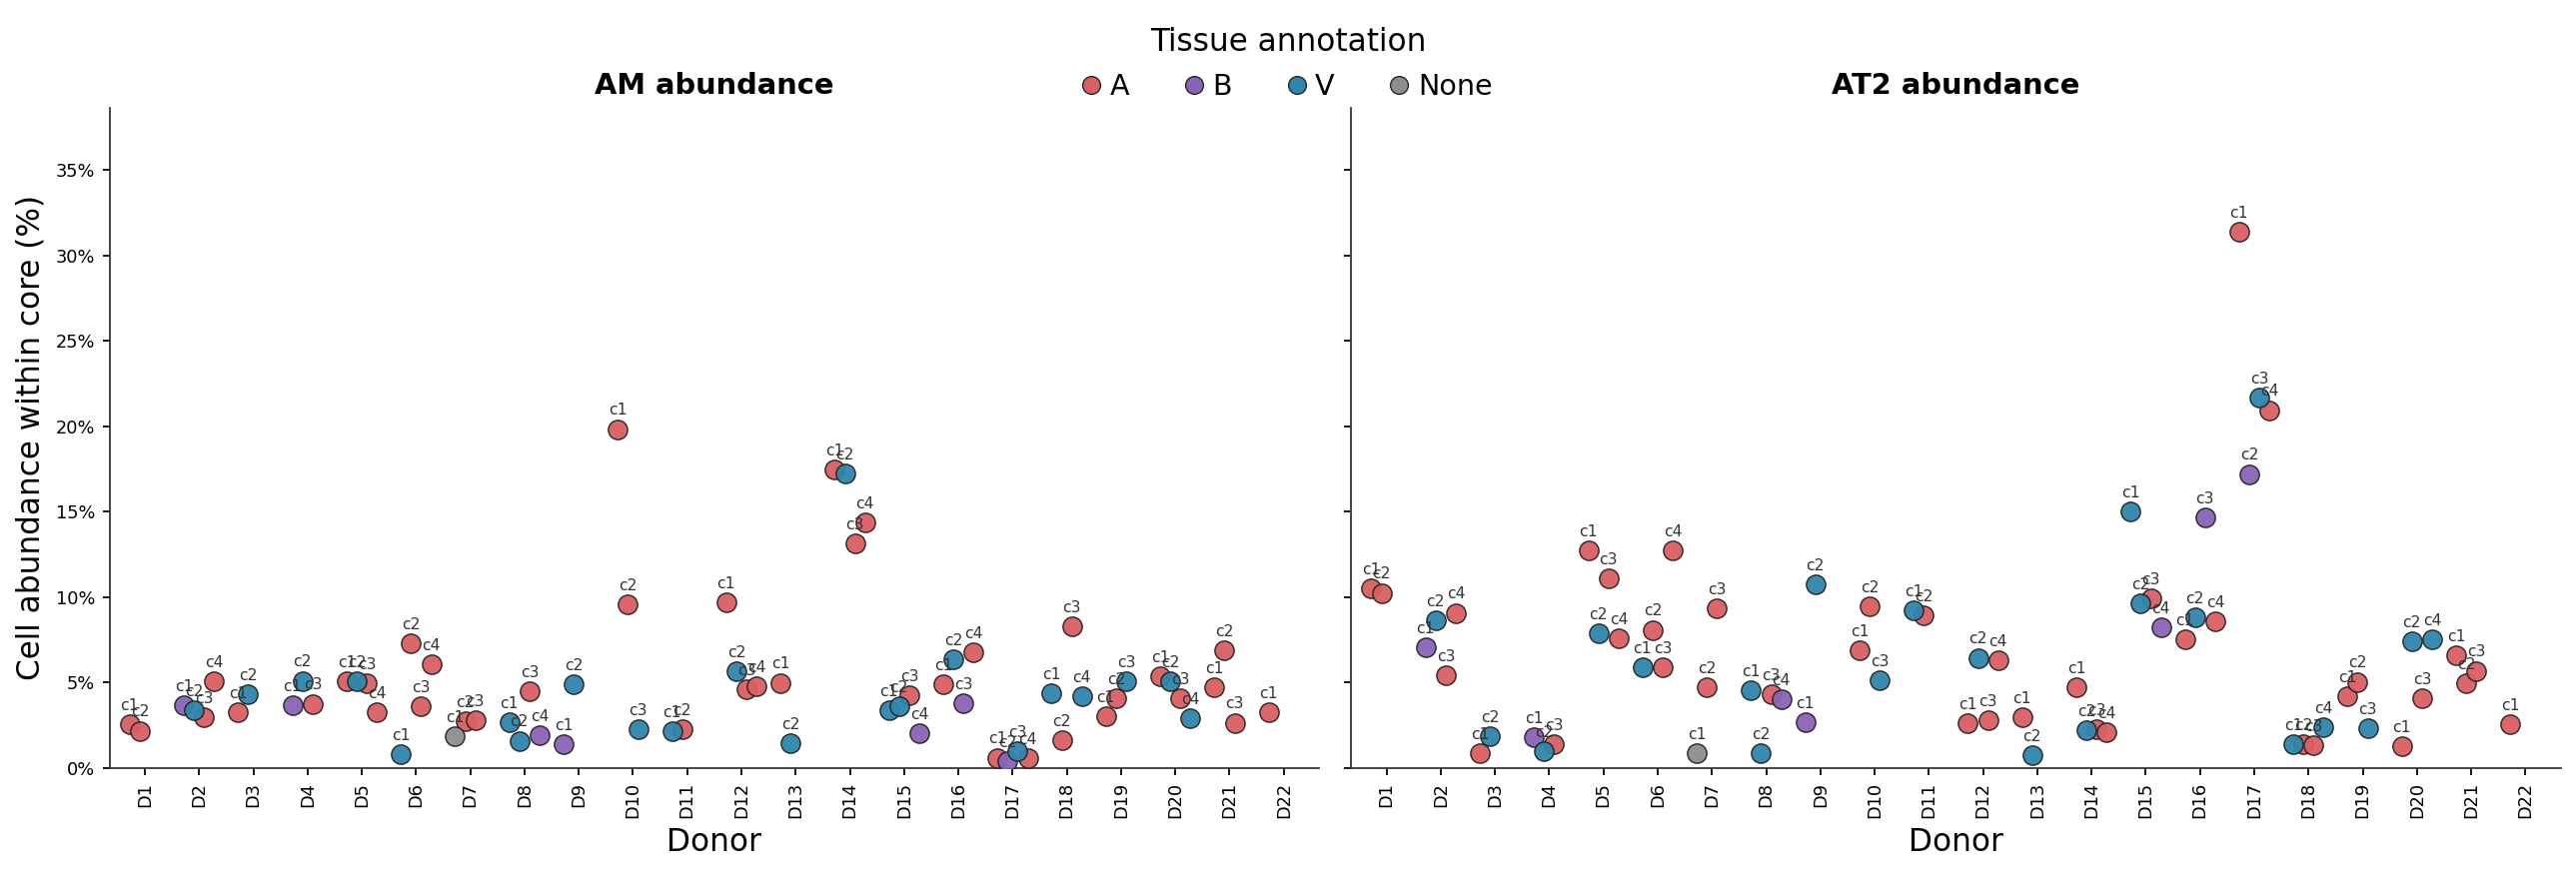

In [16]:
fig, axes, am_at2_core_summary, am_at2_core_long = (
    source.plot_am_at2_pct_by_donor(
        adata=x_all,
        celltype_col="CellType_refined",
        am_labels=(
            "AM",
            "Alveolar Macrophage",
        ),
        at2_labels=("AT2",),
        tissue_order=("A", "B", "V", "None"),
        point_size=75,
        annotate_cores=True,
        shared_y=True,
        # save="AM_AT2_percentage_by_donor_core.pdf",
    )
)

plt.show()

In [17]:
x_all.write(datadir + "all_updated.h5ad")